# Exploratory Data Analysis: Bike Sharing Demand

Цей ноутбук містить попередній аналіз даних (EDA) для набору даних "Bike Sharing Demand".

In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn mlflow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування візуалізації
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Завантаження даних

In [6]:
# Завантаження датасету
train_df = pd.read_csv('../data/raw/train.csv')

# Перегляд перших рядків
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 2. Перевірка типів даних

In [7]:
# Інформація про набір даних, типи даних та використання пам'яті
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


## 3. Перевірка пропусків

In [8]:
# Підрахунок пропущених значень по кожному стовпцю
missing_values = train_df.isnull().sum()
missing_values[missing_values > 0] if missing_values.sum() > 0 else print("Пропусків у даних не знайдено.")

Пропусків у даних не знайдено.


## 4. Аналіз цільової змінної (`count`)

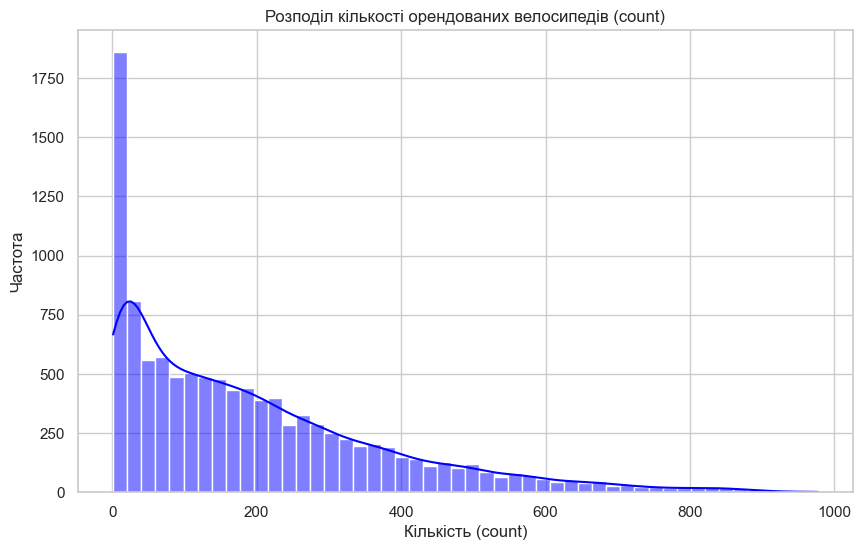

In [9]:
# Побудова графіка розподілу цільової змінної 'count'
plt.figure(figsize=(10, 6))
sns.histplot(train_df['count'], kde=True, bins=50, color='blue')
plt.title('Розподіл кількості орендованих велосипедів (count)')
plt.xlabel('Кількість (count)')
plt.ylabel('Частота')
plt.show()

## 5. Аналіз кореляції ознак

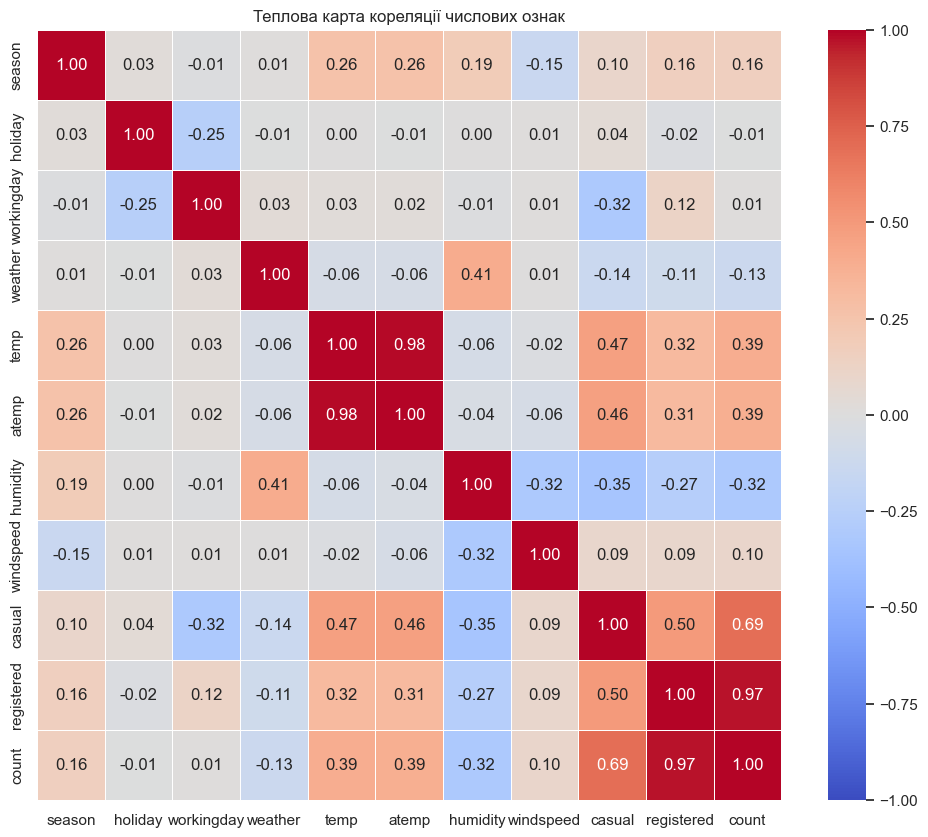

In [10]:
numeric_features = train_df.select_dtypes(include=[np.number])

# Обчислення матриці кореляції
correlation_matrix = numeric_features.corr()

# Побудова теплової карти кореляції
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
plt.title('Теплова карта кореляції числових ознак')
plt.show()